In [62]:
import warnings
warnings.filterwarnings("ignore") 
import os, time
import pandas as pd
import numpy as np
import random
import scipy.sparse as sparse
from scipy.sparse import csr_matrix, issparse

from banksy.initialize_banksy import initialize_banksy
from banksy.run_banksy import run_banksy_multiparam
from banksy_utils.color_lists import spagcn_color

import scanpy as sc
import squidpy as sq
from tqdm import tqdm
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

start = time.perf_counter_ns()
random_seed = 1234
cluster_algorithm = 'leiden'
np.random.seed(random_seed)
random.seed(random_seed)

In [63]:
from tqdm.notebook import tqdm

In [64]:
import sklearn.metrics
import gc

## Input-Ouput (IO) Options
1. Loading '.h5ad' file
2. Saving output images and '.csv' files in 'output_folder'

In [65]:
adata = sc.read_h5ad("G:/data/slidetags/HumanTonsil_2000.h5ad")

In [66]:
! mkdir slide_tags_output

A subdirectory or file slide_tags_output already exists.


In [67]:
coord_keys = ('x', 'y', 'spatial')
num_clusters = 13
annotation_key = 'cluster'
output_folder = 'slide_tags_output/'

In [68]:
resolutions = [1.] # clustering resolution for Leiden clustering
pca_dims = [60] # number of dimensions to keep after PCA
lambda_list = [.2] # lambda
k_geom = 15 # 8 spatial neighbours
max_m = 1 # use AGF
nbr_weight_decay = "scaled_gaussian" # can also be "reciprocal", "uniform" or "ranked"

In [69]:
adata.obs['x'] = adata.obsm['spatial'] [:,0]
adata.obs['y'] = adata.obsm['spatial'] [:,1]


Median distance to closest cell = 13.162909136636577

---- Ran median_dist_to_nearest_neighbour in 0.02 s ----

---- Ran generate_spatial_distance_graph in 0.04 s ----

---- Ran row_normalize in 0.03 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 0.24 s ----

----- Plotting Edge Histograms for m = 0 -----

Edge weights (distances between cells): median = 44.51081302877048, mode = 45.529551911354226

---- Ran plot_edge_histogram in 0.05 s ----


Edge weights (weights between cells): median = 0.05772687203986536, mode = 0.04194339834435362

---- Ran plot_edge_histogram in 0.05 s ----

---- Ran generate_spatial_distance_graph in 0.06 s ----

---- Ran theta_from_spatial_graph in 0.06 s ----

---- Ran row_normalize in 0.02 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 0.30 s ----

----- Plotting Edge Histograms for m = 1 -----

Edge weights (distances between cells): median = 63.39150538356155, mode = 69.48229249993267

---- Ran plot_edge_histogram in 0.05 s ----


Edge 

,decay,lambda_param,num_pcs,resolution,num_labels,labels,adata,ari
scaled_gaussian_pc60_nc0.20_r1.00,scaled_gaussian,0.2,60,1.0,14,"Label object:\nNumber of labels: 14, number of...",[[[View of AnnData object with n_obs × n_vars ...,0.370189


Anndata AxisArrays with keys: reduced_pc_60


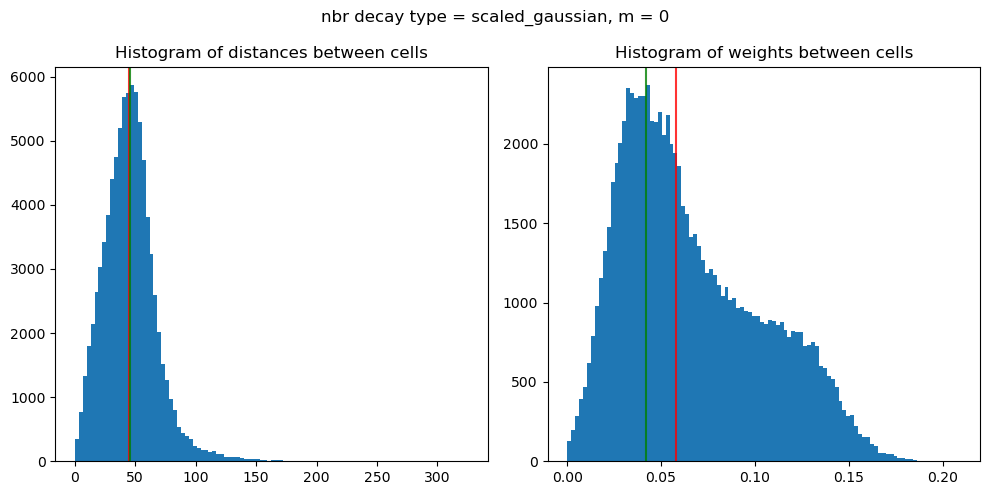

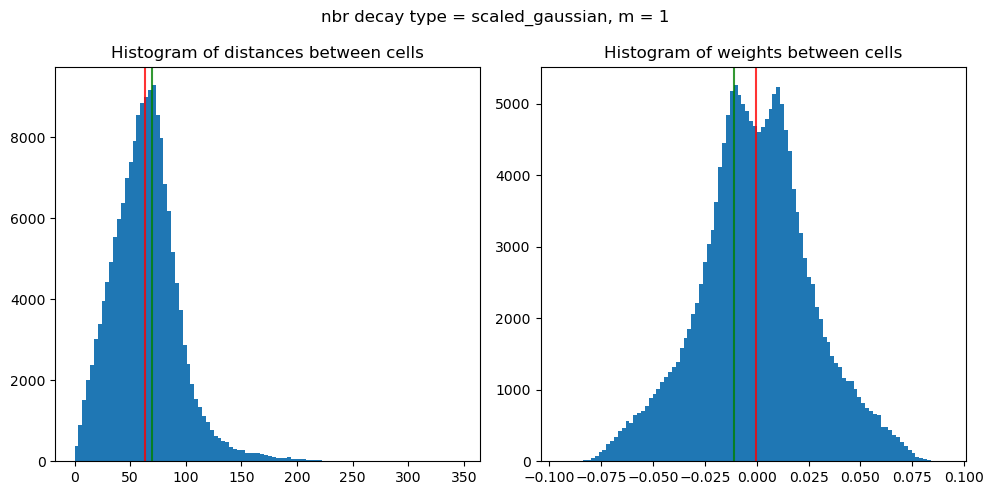

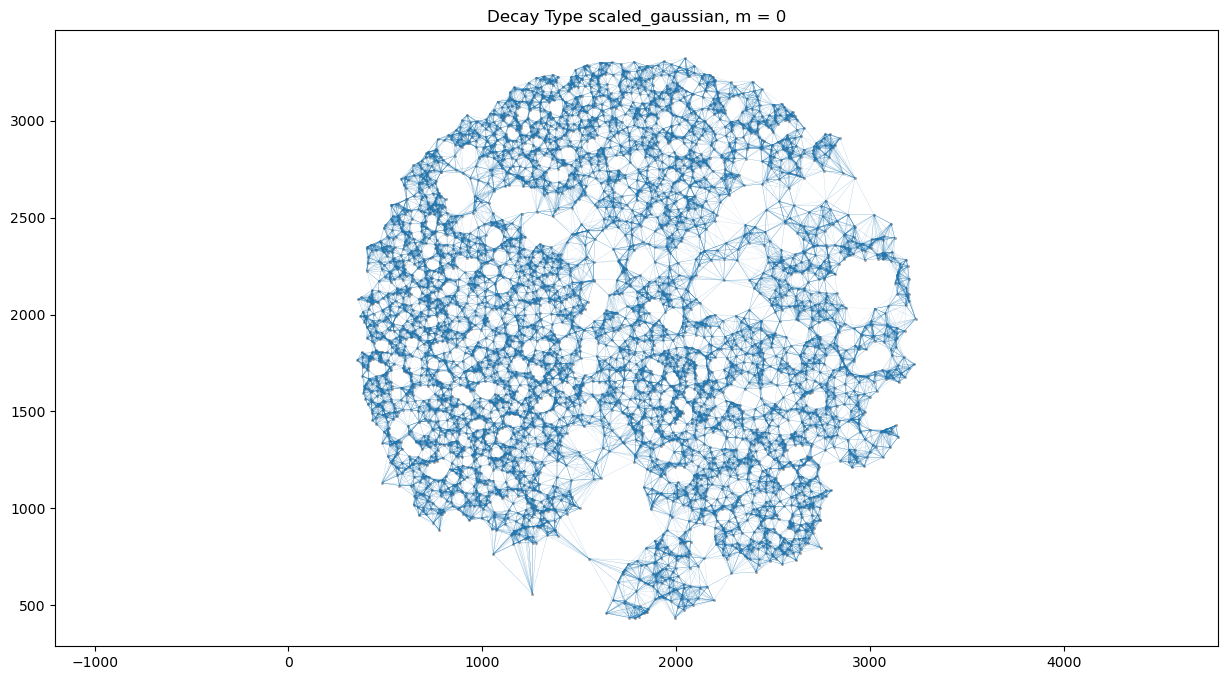

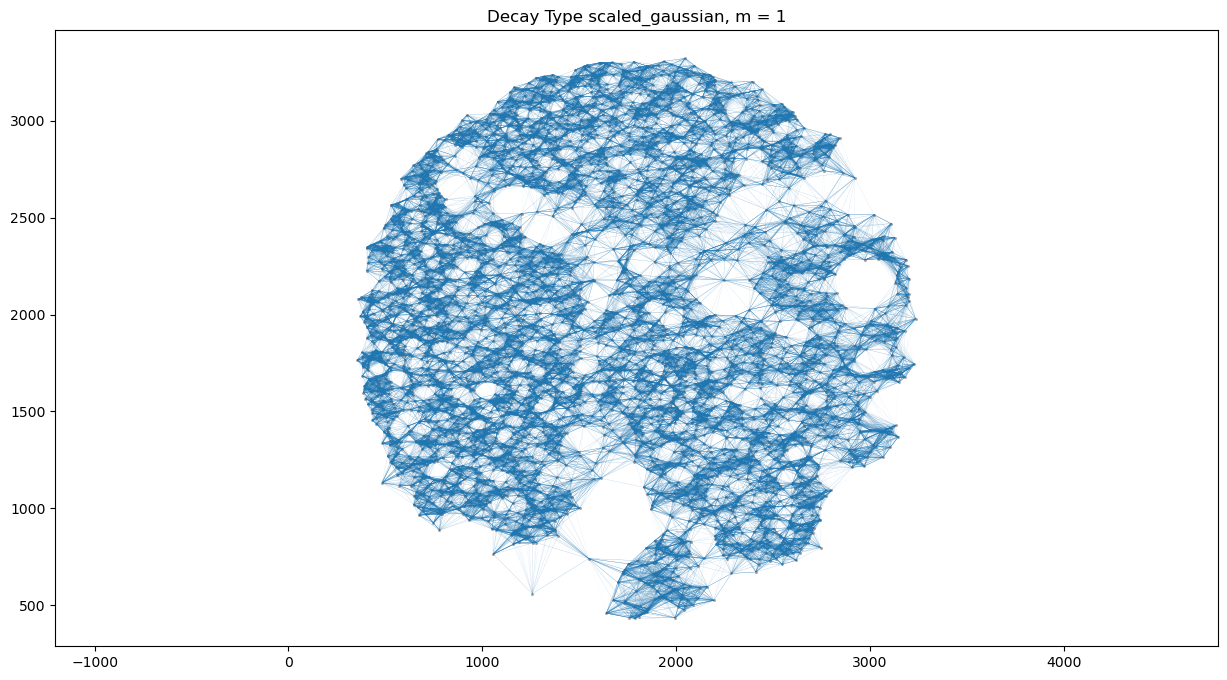

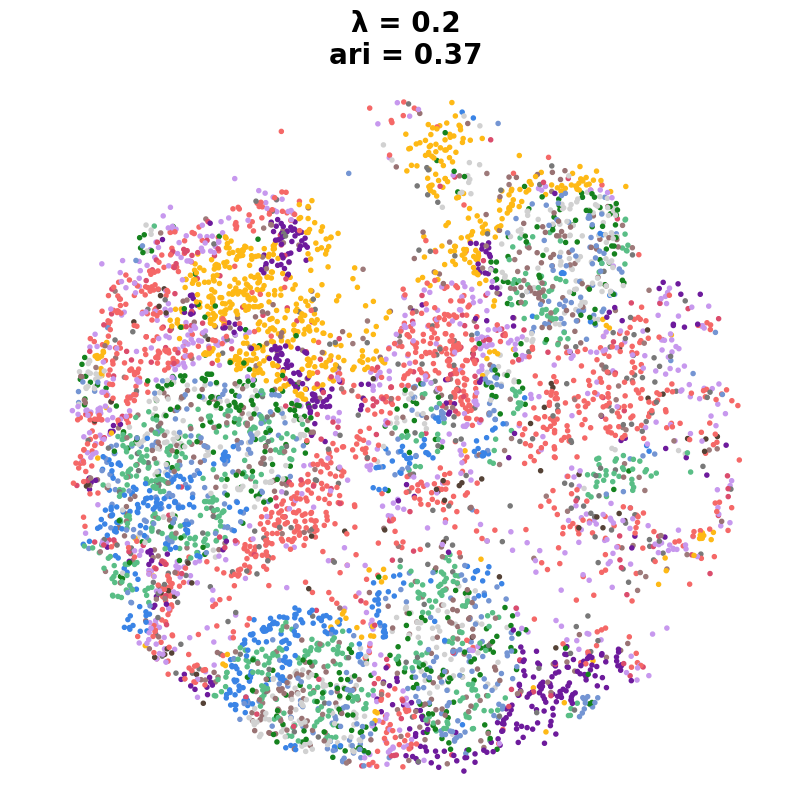

In [70]:
banksy_dict = initialize_banksy(
    adata,
    coord_keys,
    k_geom,
    nbr_weight_decay=nbr_weight_decay,
    max_m=max_m,
    plt_edge_hist=True,
    plt_nbr_weights=True,
    plt_agf_angles=False,
    plt_theta=False,
)
results_df = run_banksy_multiparam(
adata,
banksy_dict,
lambda_list,
resolutions,
color_list = spagcn_color * 10,
max_m = max_m,
filepath = output_folder,
key = coord_keys,
pca_dims = pca_dims,
annotation_key = annotation_key,
max_labels = num_clusters,
cluster_algorithm = cluster_algorithm,
match_labels = False,
savefig = False,
add_nonspatial = False,
variance_balance = False,
)
adata.obs['banksy'] = results_df['labels'][0].dense

adata.obs[['banksy']].to_csv(f"./slide_tags_output/banksy_cell_type.csv")

# Run BANKSY using defined parameters

In [71]:
ari = sklearn.metrics.adjusted_rand_score(adata.obs[annotation_key], adata.obs['banksy'])
nmi = sklearn.metrics.adjusted_mutual_info_score(adata.obs[annotation_key], adata.obs['banksy'])
n_clusters = len(adata.obs['banksy'].unique())

pd.DataFrame([n_clusters, nmi, ari], index=['n_clusters', 'NMI', 'ARI'], columns=[60]).T

,n_clusters,NMI,ARI
60,14.0,0.628903,0.370189


In [72]:
banksy_res_df = pd.DataFrame([n_clusters, nmi, ari], index=['n_clusters', 'NMI', 'ARI'], columns=[60]).T
banksy_res_df.to_csv("../Steamboat/revised/saved_results/slide_tags_banksy_res_df.csv")
banksy_res_df

,n_clusters,NMI,ARI
60,14.0,0.628903,0.370189
